# EDA

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import string
import re
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

#pip install pyldavis
import gensim
import pyLDAvis.gensim


[nltk_data] Downloading package punkt to /Users/foongming/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
# Load the dataset
data = pd.read_csv('allsides_news_data.csv')

In [3]:
# Basic info about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 863 entries, 0 to 862
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Unnamed: 0             863 non-null    int64 
 1   title                  863 non-null    object
 2   allsides_summary_text  860 non-null    object
 3   external_link          863 non-null    object
 4   bias                   863 non-null    object
dtypes: int64(1), object(4)
memory usage: 33.8+ KB


In [4]:
data = data.rename(columns={'title': 'Title'})
data = data.rename(columns={'allsides_summary_text': 'Text'})
data = data.rename(columns={'bias': 'Bias'})
data = data.rename(columns={'external_link': 'Link'})

In [5]:
# Checking for missing values
missing_values = data.isnull().sum()
print(missing_values)

Unnamed: 0    0
Title         0
Text          3
Link          0
Bias          0
dtype: int64


In [6]:
# Drop rows with any null (NaN) values
data = data.dropna()

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 860 entries, 0 to 862
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  860 non-null    int64 
 1   Title       860 non-null    object
 2   Text        860 non-null    object
 3   Link        860 non-null    object
 4   Bias        860 non-null    object
dtypes: int64(1), object(4)
memory usage: 40.3+ KB


In [7]:
# Drop rows where 'Text' column contains 'Error fetching article'
data = data[data['Text'] != 'Error fetching article']

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 860 entries, 0 to 862
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  860 non-null    int64 
 1   Title       860 non-null    object
 2   Text        860 non-null    object
 3   Link        860 non-null    object
 4   Bias        860 non-null    object
dtypes: int64(1), object(4)
memory usage: 40.3+ KB


In [8]:
def fix_encoding(text):
    # Fix common encoding issues

    text = (text
            .replace('Ã', 'A')
            .replace('Ã“', 'O')
            .replace('Ã§', 'c')
            .replace('Ã¢', 'a')
            .replace('Ã«', 'e')
            .replace('Ã¼', 'u')
            .replace('Ã¯', 'i')
            .replace('â€‘', '-')
            .replace('Ã', 'i')
            .replace('Ãº', 'u')
            .replace('â€‘', ' ')
            .replace('ðŸ¦Ž', ' ')
            .replace('Ã±', 'n')
            .replace('ðŸš¨', '')
            .replace('ðŸ”¥', '')
            .replace('Ã‰', '')
            .replace('â€‚', '')
            .replace('Ã¨', 'e')
            .replace('Ã©', 'e')
            .replace('â„¢', '')
            .replace('Ã¸', 'ø')
            .replace('\xad', '')
            .replace('Ã¡', 'a')
            .replace('Ã³','o')
            .replace('Ã¶', 'o')
            .replace('â€˜', "'")
            .replace('â€“', '-')
            .replace('â€”', '-')
            .replace('â€™', "'")
            .replace('â€œ', '"')
            .replace('â€', '"')
            .replace('â€™','"'))
    return text

## fix encoding issues
for col in ['Title', 'Text', 'Bias']:
    data[col] = data[col].apply(lambda x: fix_encoding(x))

## create helper columns
whitelist_pattern = r"[a-zA-Z\s0-9.$(),\'\":\-\?\[\]\!\%\&;\@\/\*\+\#ø£\=\_]"
t = data['Text'].apply(lambda x: re.sub(whitelist_pattern, '', x))
data['special_symbol_length'] = t.str.len()
data['special_symbol_proportion'] = data['special_symbol_length'] / data['Text'].str.len()
proportion = 0.0014

## filter out high proportions of special symbols - these are non english articles
data = data[~((data['special_symbol_proportion'] > proportion))]

## clean up text of special symbols
special_char_pattern = rf"[^{whitelist_pattern}]"
data['cleaned_text'] = data['Text'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

def cols_to_string(data: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    for col in cols:
        data[col] = data[col].astype(str)
    return data

# Convert the data to strings 
data = cols_to_string(data, ['Title', 'Text', 'Link', 'Bias'])

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 320 entries, 1 to 861
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 320 non-null    int64  
 1   Title                      320 non-null    object 
 2   Text                       320 non-null    object 
 3   Link                       320 non-null    object 
 4   Bias                       320 non-null    object 
 5   special_symbol_length      320 non-null    int64  
 6   special_symbol_proportion  320 non-null    float64
 7   cleaned_text               320 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 22.5+ KB


In [9]:
# Show the first few rows of the dataset
data.head()

,Unnamed: 0,Title,Text,Link,Bias,special_symbol_length,special_symbol_proportion,cleaned_text
1,1,ICC sent Hungary a request to arrest and surre...,The International Criminal Court (ICC) sent a ...,https://www.timesofisrael.com/icc-sent-hungary...,Center,0,0.0,The International Criminal Court ICC sent a re...
2,2,US defends tariffs on remote island of penguin...,The US Commerce Secretary has defended the cou...,https://www.bbc.com/news/articles/ce84jr5mvnno,Center,0,0.0,The US Commerce Secretary has defended the cou...
5,5,"GOP Rep: Adversaries are ""laughing at us"" over...",Rep. Don Bacon (R-Neb.) slammed the decision t...,https://www.axios.com/2025/04/06/nsc-nsa-firin...,Lean Left,0,0.0,Rep Don Bacon RNeb slammed the decision to fir...
7,7,Fans left baffled as FBI boss Kash Patel sits ...,Already facing criticism over his ties to Pres...,https://www.dailymail.co.uk/sport/nhl/article-...,Right,0,0.0,Already facing criticism over his ties to Pres...
12,12,Trump's tariff 'medicine' engulfs markets as U...,President Donald Trump's sweeping tariff plans...,https://www.reuters.com/world/trumps-tariff-me...,Center,0,0.0,President Donald Trumps sweeping tariff plans ...


In [10]:
# Summary statistics of numerical columns (if any)
data.describe()

,Unnamed: 0,special_symbol_length,special_symbol_proportion
count,320.000000,320.0,320.0
mean,18.084375,0.0,0.0
std,14.540045,0.0,0.0
min,0.000000,0.0,0.0
25%,6.000000,0.0,0.0
50%,15.000000,0.0,0.0
75%,28.000000,0.0,0.0
max,55.000000,0.0,0.0


In [11]:
# same as original data EDA 
data = data.drop_duplicates(subset='Title', keep='first')
data = data.drop_duplicates(subset='Text', keep='first')
data = data.drop_duplicates(subset='Link', keep='first')

In [12]:
# Verify by checking the data info
data.describe()

,Unnamed: 0,special_symbol_length,special_symbol_proportion
count,320.000000,320.0,320.0
mean,18.084375,0.0,0.0
std,14.540045,0.0,0.0
min,0.000000,0.0,0.0
25%,6.000000,0.0,0.0
50%,15.000000,0.0,0.0
75%,28.000000,0.0,0.0
max,55.000000,0.0,0.0


## Distribution of Bias over dataset

In [13]:
# Checking the distribution of the 'Bias' column
bias_counts = data['Bias'].value_counts()
print(bias_counts)
# over representation of left bias

Bias
Center        143
Lean Left      68
Right          56
Lean Right     37
Left           16
Name: count, dtype: int64


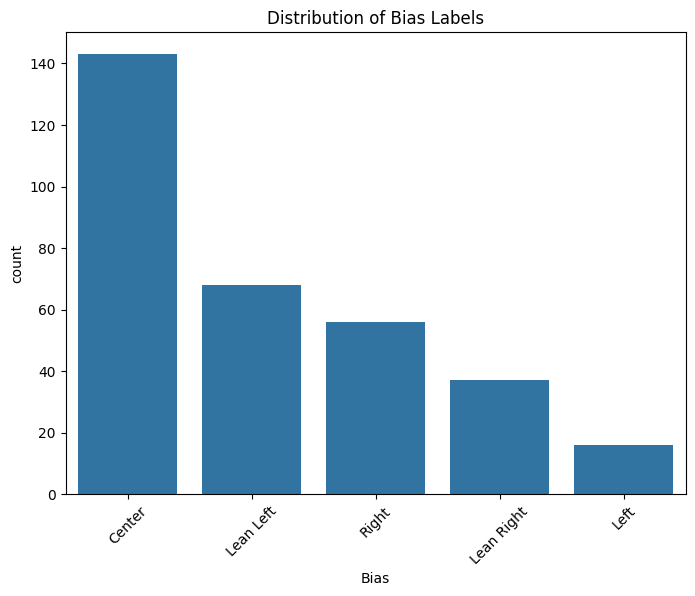

In [14]:
# Visualizing the distribution of Bias labels
plt.figure(figsize=(8,6))
sns.countplot(data=data, x='Bias', order=data['Bias'].value_counts().index)
plt.title('Distribution of Bias Labels')
plt.xticks(rotation=45)
plt.show()

In [15]:
# Here we remove source name from article text so as to remove the predictors from the text
# This allows our model to generalise to sources outside the training data 

# We also know that news articles then to cite other sources in their articles. this removal also address this conflating factor

# Define regex patterns for each source name.
# These patterns account for optional spaces between words.
source_patterns = [
    r'\bAlternet\b',
    r'\bAP\s*News\b',                   # Matches "APNews" or "AP News"
    r'\bBlaze\s*Media\b',
    r'\bBreit\s*Bart\b',
    r'\bHuff\s*post\b',                  # Matches "Huffpost" or "Huff post"
    r'\bIndependent\s*Journal\s*Review\b',
    r'\bMother\s*Jones\b',
    r'\bNew\s*York\s*Post\b',
    r'\bStraight\s*Arrow\s*News\b',
    r'\bThe\s*Daily\s*Beast\b',
    r'\bThe\s*Dispatch\b',
    r'\bThe\s*Federalist\b',
    r'\bThe\s*Free\s*Press\b',
    r'\bThe\s*Nation\b',
    r'\bThe\s*Washington\s*Free\s*Beacon\b',
    r'\babc\s*news\b',
    r'\bcnbc\b',
    r'\bnbc\s*news\b',
    r'\bnpr\b',
    r'\busa\s*today\b'
]

# Combine the individual patterns into one regex pattern.
combined_pattern = re.compile("|".join(source_patterns), flags=re.IGNORECASE)

def remove_source_names(text):
    """
    Removes occurrences of known source names from the input text using the combined regex.
    """
    # Replace any match with an empty string
    return combined_pattern.sub("", text)

# create a copy to store the modified text
df_stripped = data.copy()

# Apply the removal function to the 'Text' column
df_stripped['stripped_text'] = df_stripped['Text'].apply(remove_source_names)

# calculate word counts before and after source removal
df_stripped['Text_length'] = df_stripped['Text'].apply(lambda x: len(x.split()))
df_stripped['stripped_len'] = df_stripped['stripped_text'].apply(lambda x: len(x.split()))
df_stripped['text_length_diff'] = df_stripped['Text_length'] - df_stripped['stripped_len']

In [16]:
# Display the first few rows of the new DataFrame.
df_stripped.head()

,Unnamed: 0,Title,Text,Link,Bias,special_symbol_length,special_symbol_proportion,cleaned_text,stripped_text,Text_length,stripped_len,text_length_diff
1,1,ICC sent Hungary a request to arrest and surre...,The International Criminal Court (ICC) sent a ...,https://www.timesofisrael.com/icc-sent-hungary...,Center,0,0.0,The International Criminal Court ICC sent a re...,The International Criminal Court (ICC) sent a ...,82,82,0
2,2,US defends tariffs on remote island of penguin...,The US Commerce Secretary has defended the cou...,https://www.bbc.com/news/articles/ce84jr5mvnno,Center,0,0.0,The US Commerce Secretary has defended the cou...,The US Commerce Secretary has defended the cou...,90,90,0
5,5,"GOP Rep: Adversaries are ""laughing at us"" over...",Rep. Don Bacon (R-Neb.) slammed the decision t...,https://www.axios.com/2025/04/06/nsc-nsa-firin...,Lean Left,0,0.0,Rep Don Bacon RNeb slammed the decision to fir...,Rep. Don Bacon (R-Neb.) slammed the decision t...,80,80,0
7,7,Fans left baffled as FBI boss Kash Patel sits ...,Already facing criticism over his ties to Pres...,https://www.dailymail.co.uk/sport/nhl/article-...,Right,0,0.0,Already facing criticism over his ties to Pres...,Already facing criticism over his ties to Pres...,99,99,0
12,12,Trump's tariff 'medicine' engulfs markets as U...,President Donald Trump's sweeping tariff plans...,https://www.reuters.com/world/trumps-tariff-me...,Center,0,0.0,President Donald Trumps sweeping tariff plans ...,President Donald Trump's sweeping tariff plans...,75,75,0


In [17]:
# Calculate the average number of words removed per article
average_words_removed = df_stripped['text_length_diff'].mean()
print("Average number of words removed per article:", average_words_removed)

Average number of words removed per article: 0.065625


In [18]:
# Count the number of rows with text removed
num_articles_removed = df_stripped[df_stripped['text_length_diff'] > 0].shape[0]

# Total number of articles
total_articles = df_stripped.shape[0]

# Calculate the percentage of articles with text removed
percentage_removed = (num_articles_removed / total_articles) * 100

print("Number of articles with text removed:", num_articles_removed)
print("Percentage of articles with text removed: {:.2f}%".format(percentage_removed))

Number of articles with text removed: 13
Percentage of articles with text removed: 4.06%


## Analyse Length

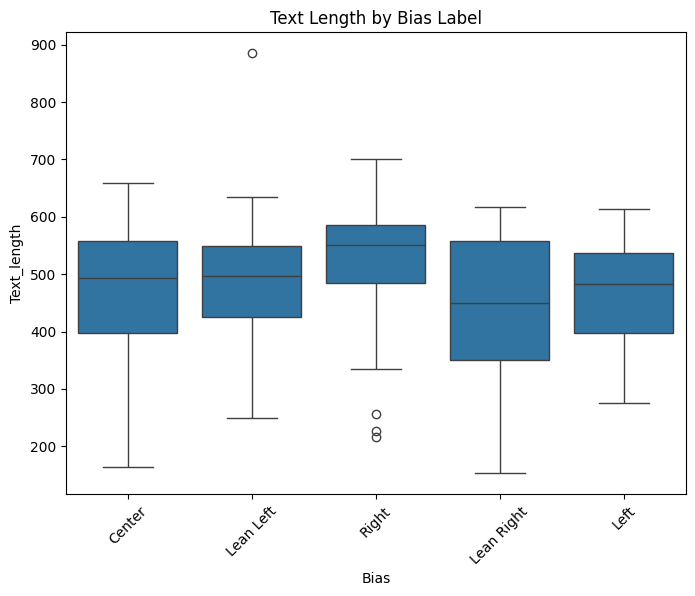

In [19]:
# Investigating length of articles by bias
data['Text_length'] = data['Text'].apply(len)

plt.figure(figsize=(8,6))
sns.boxplot(data=data, x='Bias', y='Text_length')
plt.title('Text Length by Bias Label')
plt.xticks(rotation=45)
plt.show()

In [20]:
# Group by 'Bias' and get text length analysis for each group
grouped_description = data.groupby('Bias').describe()

# Display the result
print(grouped_description)

           Unnamed: 0                                                     \
                count       mean        std  min   25%   50%   75%   max   
Bias                                                                       
Center          143.0  17.636364  14.633333  0.0  6.00  14.0  26.0  55.0   
Lean Left        68.0  19.838235  14.731032  0.0  7.75  17.0  30.0  54.0   
Lean Right       37.0  18.729730  15.209004  1.0  5.00  13.0  35.0  51.0   
Left             16.0  18.250000  11.812423  2.0  9.25  17.5  24.5  45.0   
Right            56.0  16.625000  14.585874  0.0  6.00  13.5  24.0  54.0   

           special_symbol_length       ... special_symbol_proportion       \
                           count mean  ...                       75%  max   
Bias                                   ...                                  
Center                     143.0  0.0  ...                       0.0  0.0   
Lean Left                   68.0  0.0  ...                       0.0  0.0   
Lean R

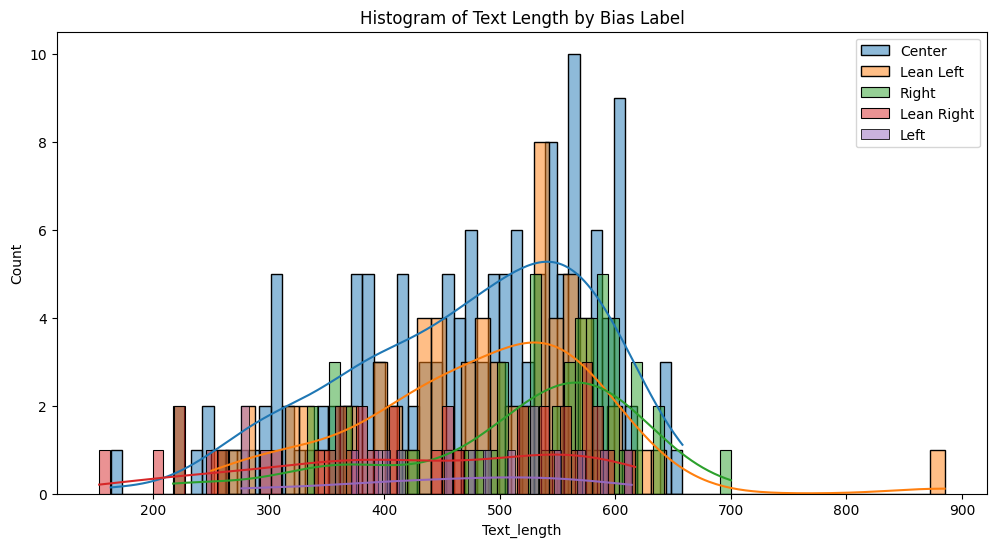

In [21]:
plt.figure(figsize=(12,6))
for bias_label in data['Bias'].unique():
    sns.histplot(data[data['Bias'] == bias_label]['Text_length'], kde=True, label=bias_label, bins=50)
plt.legend()
plt.title("Histogram of Text Length by Bias Label")
plt.show()

## Analyse Distribution of Vocabulary

In [22]:
# Dictionary to store unique word count for each Bias label
unique_word_counts = {}

# Iterate through unique Bias labels
for bias_label in df_stripped['Bias'].unique():
    # Concatenate all text for the current bias label
    all_text = " ".join(df_stripped[df_stripped['Bias'] == bias_label]['Text'])
    
    # Get unique words
    unique_words = set(all_text.split())
    
    # Store the count in the dictionary
    unique_word_counts[bias_label] = len(unique_words)

# Sort the dictionary by values in descending order
sorted_unique_word_counts = dict(sorted(unique_word_counts.items(), key=lambda item: item[1], reverse=True))

# Print the sorted dictionary
print(sorted_unique_word_counts)

{'Center': 3896, 'Lean Left': 2225, 'Right': 2099, 'Lean Right': 1373, 'Left': 697}


In [23]:
# Function to compute unique word count for each row
def unique_word_count(text):
    return len(set(str(text).split()))

# Add a new column for per-row unique word count
df_stripped['unique_word_count'] = df_stripped['stripped_text'].apply(unique_word_count)

# Display the first few rows of the updated DataFrame
df_stripped.head()

,Unnamed: 0,Title,Text,Link,Bias,special_symbol_length,special_symbol_proportion,cleaned_text,stripped_text,Text_length,stripped_len,text_length_diff,unique_word_count
1,1,ICC sent Hungary a request to arrest and surre...,The International Criminal Court (ICC) sent a ...,https://www.timesofisrael.com/icc-sent-hungary...,Center,0,0.0,The International Criminal Court ICC sent a re...,The International Criminal Court (ICC) sent a ...,82,82,0,56
2,2,US defends tariffs on remote island of penguin...,The US Commerce Secretary has defended the cou...,https://www.bbc.com/news/articles/ce84jr5mvnno,Center,0,0.0,The US Commerce Secretary has defended the cou...,The US Commerce Secretary has defended the cou...,90,90,0,70
5,5,"GOP Rep: Adversaries are ""laughing at us"" over...",Rep. Don Bacon (R-Neb.) slammed the decision t...,https://www.axios.com/2025/04/06/nsc-nsa-firin...,Lean Left,0,0.0,Rep Don Bacon RNeb slammed the decision to fir...,Rep. Don Bacon (R-Neb.) slammed the decision t...,80,80,0,72
7,7,Fans left baffled as FBI boss Kash Patel sits ...,Already facing criticism over his ties to Pres...,https://www.dailymail.co.uk/sport/nhl/article-...,Right,0,0.0,Already facing criticism over his ties to Pres...,Already facing criticism over his ties to Pres...,99,99,0,80
12,12,Trump's tariff 'medicine' engulfs markets as U...,President Donald Trump's sweeping tariff plans...,https://www.reuters.com/world/trumps-tariff-me...,Center,0,0.0,President Donald Trumps sweeping tariff plans ...,President Donald Trump's sweeping tariff plans...,75,75,0,65


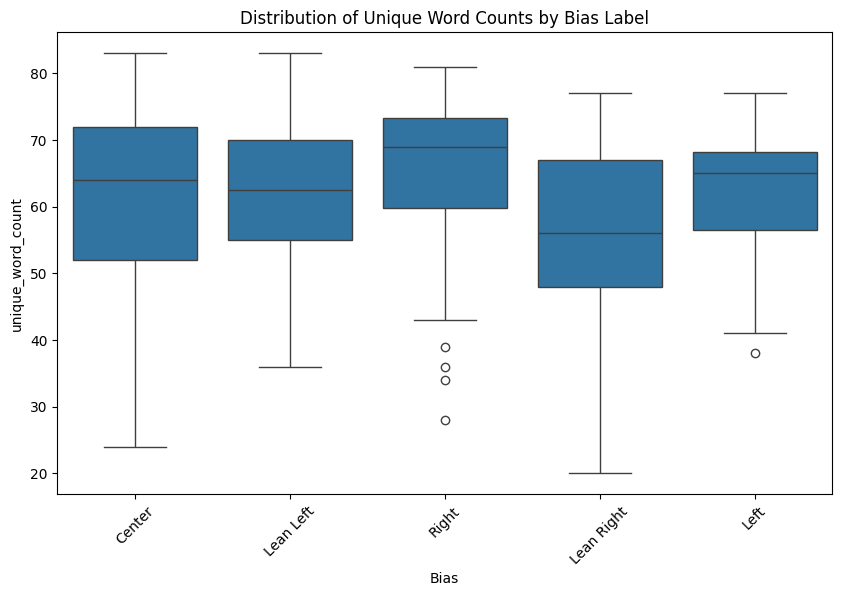

In [24]:
# Visualize distributions
plt.figure(figsize=(10,6))
sns.boxplot(x=data['Bias'], y=df_stripped['unique_word_count'])
plt.xticks(rotation=45)
plt.title("Distribution of Unique Word Counts by Bias Label")
plt.show()

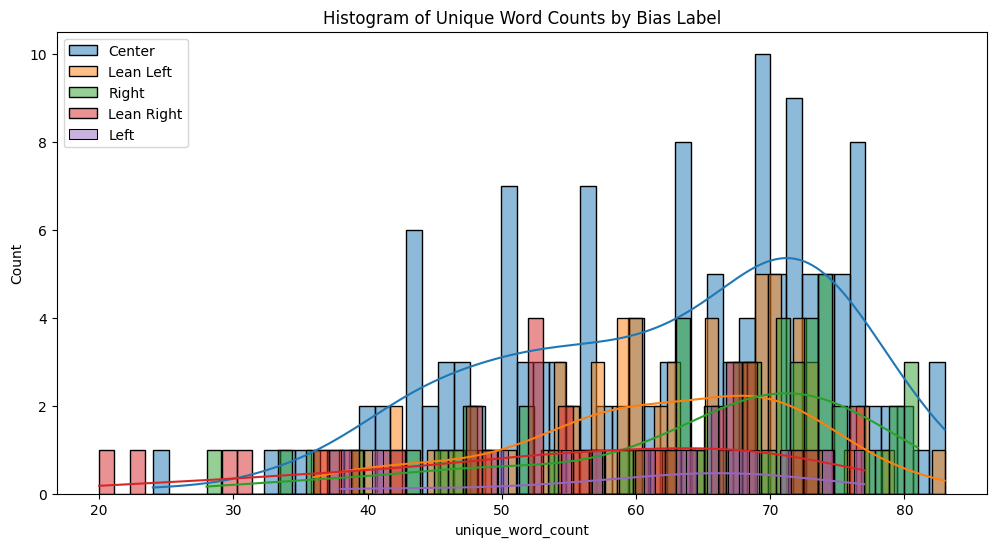

In [25]:
plt.figure(figsize=(12,6))
for bias_label in df_stripped['Bias'].unique():
    sns.histplot(df_stripped[df_stripped['Bias'] == bias_label]['unique_word_count'], kde=True, label=bias_label, bins=50)
plt.legend()
plt.title("Histogram of Unique Word Counts by Bias Label")
plt.show()

## Analyse Text Content 

In [26]:
# Define a set of English stopwords
stop_words = set(stopwords.words('english'))

def clean_and_stem_text(text):
    """
    Clean, remove stopwords, and stem text.
    
    Steps:
    1. Convert text to lowercase.
    2. Remove punctuation and non-alphabetic characters.
    3. Tokenize the text.
    4. Remove stopwords.
    5. Apply stemming on each token.
    6. Rejoin tokens into a cleaned string.
    """
    # Convert text to lowercase
    text = text.lower()
    
    # Remove punctuation and non-letter characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize the text into words
    tokens = nltk.word_tokenize(text)
    
    # Remove stopwords
    tokens = [token for token in tokens if token not in stop_words]
    
    # Initialize the stemmer
    stemmer = PorterStemmer()
    
    # Stem each token
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    
    # Rejoin the stemmed tokens into a single string
    cleaned_text = ' '.join(stemmed_tokens)
    return cleaned_text

# Example usage:
sample_text = "Running, runners ran and are running quickly! But they weren't too happy about it."
print(clean_and_stem_text(sample_text))

run runner ran run quickli werent happi


In [27]:
# Apply the clean_text function to the 'Text' column
df_stripped['cleaned_text'] = df_stripped['stripped_text'].apply(clean_and_stem_text)

# Most common words (excluding stopwords)
words = ' '.join(df_stripped['cleaned_text']).split()
word_counts = Counter(words)
most_common_words = word_counts.most_common(20)

# Display the 20 most common words
common_words_df = pd.DataFrame(most_common_words, columns=['Word', 'Frequency'])
common_words_df

,Word,Frequency
0,trump,220
1,us,183
2,presid,149
3,said,117
4,administr,101
5,state,91
6,donald,88
7,govern,82
8,feder,78
9,court,65


In [28]:
df_stripped

,Unnamed: 0,Title,Text,Link,Bias,special_symbol_length,special_symbol_proportion,cleaned_text,stripped_text,Text_length,stripped_len,text_length_diff,unique_word_count
1,1,ICC sent Hungary a request to arrest and surre...,The International Criminal Court (ICC) sent a ...,https://www.timesofisrael.com/icc-sent-hungary...,Center,0,0.0,intern crimin court icc sent request hungarian...,The International Criminal Court (ICC) sent a ...,82,82,0,56
2,2,US defends tariffs on remote island of penguin...,The US Commerce Secretary has defended the cou...,https://www.bbc.com/news/articles/ce84jr5mvnno,Center,0,0.0,us commerc secretari defend countri decis impo...,The US Commerce Secretary has defended the cou...,90,90,0,70
5,5,"GOP Rep: Adversaries are ""laughing at us"" over...",Rep. Don Bacon (R-Neb.) slammed the decision t...,https://www.axios.com/2025/04/06/nsc-nsa-firin...,Lean Left,0,0.0,rep bacon rneb slam decis fire gen timothi hau...,Rep. Don Bacon (R-Neb.) slammed the decision t...,80,80,0,72
7,7,Fans left baffled as FBI boss Kash Patel sits ...,Already facing criticism over his ties to Pres...,https://www.dailymail.co.uk/sport/nhl/article-...,Right,0,0.0,alreadi face critic tie presid donald trump wa...,Already facing criticism over his ties to Pres...,99,99,0,80
12,12,Trump's tariff 'medicine' engulfs markets as U...,President Donald Trump's sweeping tariff plans...,https://www.reuters.com/world/trumps-tariff-me...,Center,0,0.0,presid donald trump sweep tariff plan hammer g...,President Donald Trump's sweeping tariff plans...,75,75,0,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,2,'Nothing has been done': Judge slams DOJ in ca...,The federal judge overseeing the case of Kilma...,https://abcnews.go.com/US/after-supreme-court-...,Lean Left,0,0.0,feder judg overse case kilmar armando abrego g...,The federal judge overseeing the case of Kilma...,91,91,0,73
854,3,"Consumer sentiment plunges 11% in April, fourt...",A University of Michigan of Michigan survey F...,https://www.upi.com/Top_News/US/2025/04/11/con...,Center,0,0.0,univers michigan michigan survey friday found ...,A University of Michigan of Michigan survey F...,44,44,0,34
855,4,"US Base Commander Goes Rogue, Separates Base f...",Remember when Space Force was the punching bag...,https://www.westernjournal.com/us-base-command...,Right,0,0.0,rememb space forc punch bag liber coast coast ...,Remember when Space Force was the punching bag...,95,95,0,67
858,7,Federal judge sides with Trump on immigration ...,"A federal judge on Friday, April 11, sided wit...",https://www.ncronline.org/news/federal-judge-s...,Right,0,0.0,feder judg friday april side trump administr a...,"A federal judge on Friday, April 11, sided wit...",90,90,0,70


In [29]:
total_words = sum(word_counts.values())
print(total_words)

14831


In [30]:
common_words_df['Percentage'] = (common_words_df['Frequency'] / total_words) * 100

In [31]:
common_words_df.head(20)

,Word,Frequency,Percentage
0,trump,220,1.483379
1,us,183,1.233902
2,presid,149,1.004652
3,said,117,0.788888
4,administr,101,0.681006
5,state,91,0.613580
6,donald,88,0.593352
7,govern,82,0.552896
8,feder,78,0.525925
9,court,65,0.438271


In [32]:
# Check types of entries in the 'cleaned_text' column
non_string_entries = df_stripped[~df_stripped['cleaned_text'].apply(lambda x: isinstance(x, str))]
print("Non-string entries found:")
print(non_string_entries[['cleaned_text', 'Bias']])

Non-string entries found:
Empty DataFrame
Columns: [cleaned_text, Bias]
Index: []


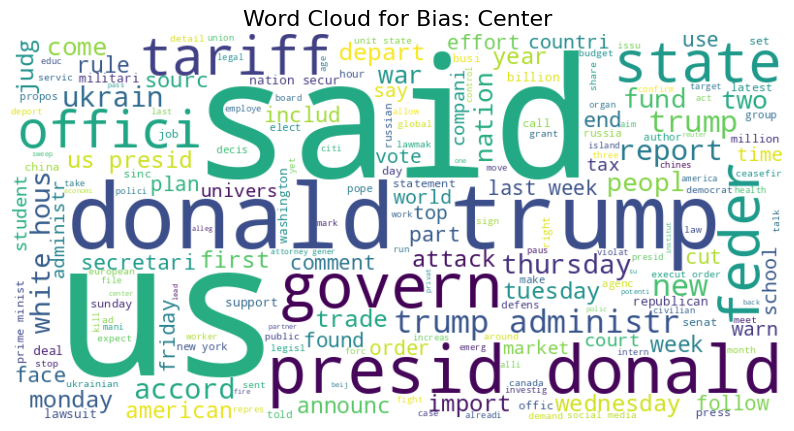

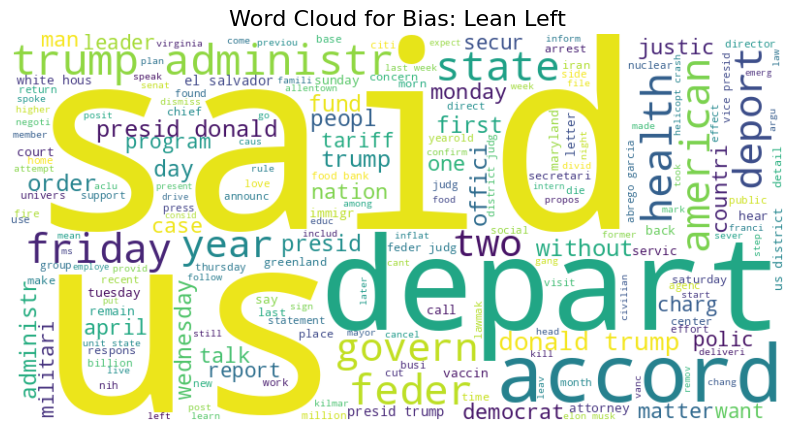

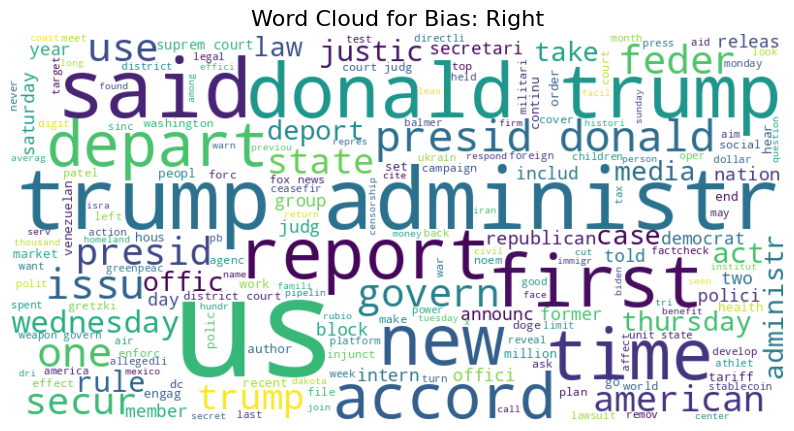

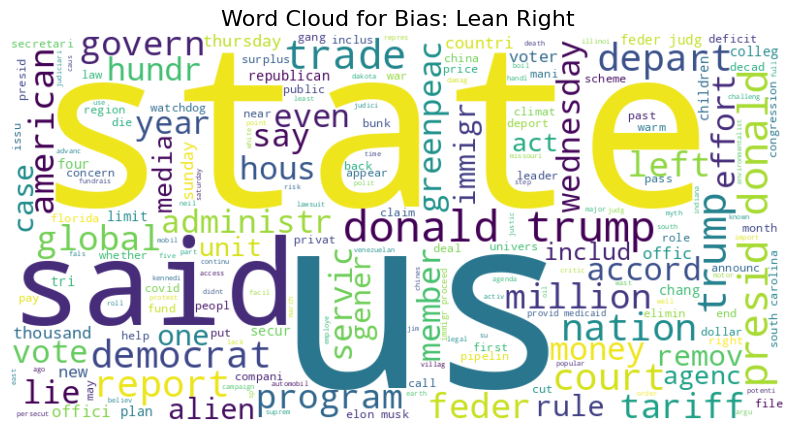

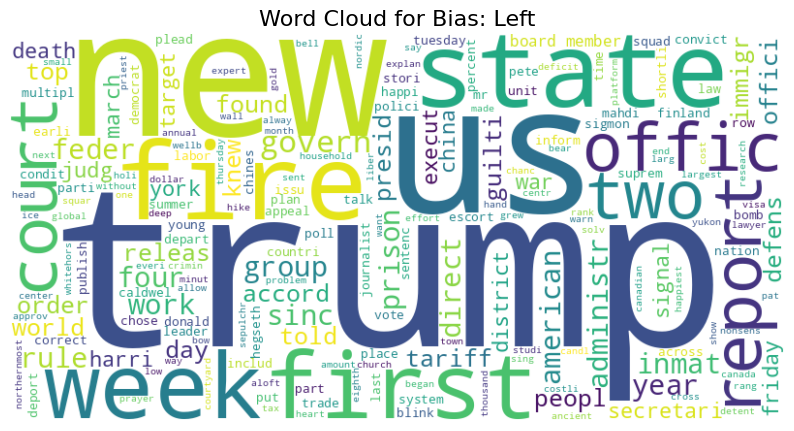

In [33]:
# Get unique bias values
biases = df_stripped['Bias'].unique()

# Iterate over each bias and generate a word cloud
for bias in biases:
    # Filter the DataFrame for the current bias
    bias_text = ' '.join(df_stripped[df_stripped['Bias'] == bias]['cleaned_text'])
    
    # Generate the word cloud for the current bias
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(bias_text)
    
    # Plot the word cloud
    plt.figure(figsize=(10, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for Bias: {bias}', fontsize=16)
    plt.axis('off')
    plt.show()

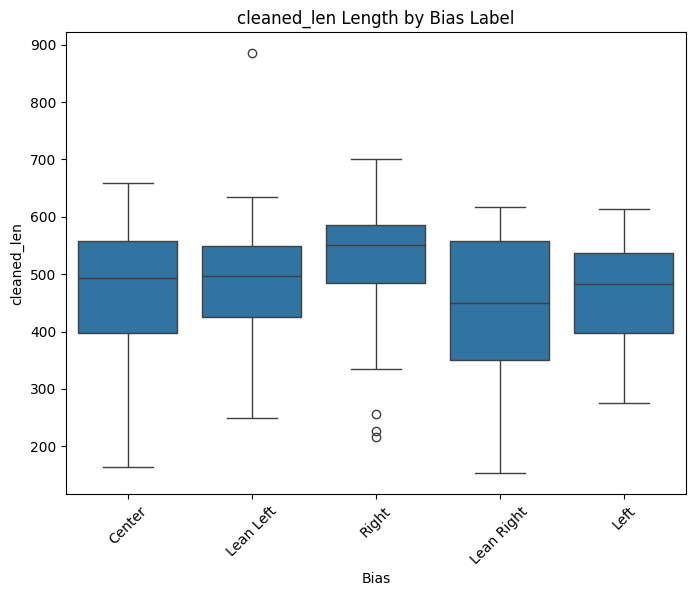

In [34]:
# Investigating length of cleaned articles by bias
df_stripped['cleaned_len'] = df_stripped['Text'].apply(len)

plt.figure(figsize=(8,6))
sns.boxplot(data=df_stripped, x='Bias', y='cleaned_len')
plt.title('cleaned_len Length by Bias Label')
plt.xticks(rotation=45)
plt.show()

In [35]:
# Define stopwords set
stop = set(stopwords.words('english'))

def preprocess_text(text):
    corpus = []
    lem = WordNetLemmatizer()
    for news in text:
        # Ensure each news item is a string before tokenizing
        #news_str = str(news)
        words = [w for w in word_tokenize(news) if w.lower() not in stop] #check if this is redundant 
        words = [lem.lemmatize(w) for w in words if len(w) > 2]
        corpus.append(words)
    return corpus

def get_lda_by_bias(data):
    lda_models = {}
    bow_corpus_dict = {}

    for bias_label in data['Bias'].unique():
        # Use data passed to the function instead of df_stripped directly for consistency
        subset = data[data['Bias'] == bias_label]['cleaned_text'].dropna().tolist()
        corpus = preprocess_text(subset)

        dic = gensim.corpora.Dictionary(corpus)
        bow_corpus = [dic.doc2bow(doc) for doc in corpus]

        lda_model = gensim.models.LdaMulticore(
            bow_corpus, num_topics=4, id2word=dic, passes=10, workers=2
        )

        lda_models[bias_label] = lda_model
        bow_corpus_dict[bias_label] = (bow_corpus, dic)

    return lda_models, bow_corpus_dict

def plot_lda_vis(lda_model, bow_corpus, dic):
    pyLDAvis.enable_notebook()
    vis = pyLDAvis.gensim.prepare(lda_model, bow_corpus, dic)
    return vis

def show_topics_by_bias(lda_models):
    for bias_label, lda_model in lda_models.items():
        print(f"\nTopics for Bias: {bias_label}")
        topics = lda_model.print_topics(num_words=5)
        for topic in topics:
            print(topic)

In [36]:
df_stripped

,Unnamed: 0,Title,Text,Link,Bias,special_symbol_length,special_symbol_proportion,cleaned_text,stripped_text,Text_length,stripped_len,text_length_diff,unique_word_count,cleaned_len
1,1,ICC sent Hungary a request to arrest and surre...,The International Criminal Court (ICC) sent a ...,https://www.timesofisrael.com/icc-sent-hungary...,Center,0,0.0,intern crimin court icc sent request hungarian...,The International Criminal Court (ICC) sent a ...,82,82,0,56,502
2,2,US defends tariffs on remote island of penguin...,The US Commerce Secretary has defended the cou...,https://www.bbc.com/news/articles/ce84jr5mvnno,Center,0,0.0,us commerc secretari defend countri decis impo...,The US Commerce Secretary has defended the cou...,90,90,0,70,559
5,5,"GOP Rep: Adversaries are ""laughing at us"" over...",Rep. Don Bacon (R-Neb.) slammed the decision t...,https://www.axios.com/2025/04/06/nsc-nsa-firin...,Lean Left,0,0.0,rep bacon rneb slam decis fire gen timothi hau...,Rep. Don Bacon (R-Neb.) slammed the decision t...,80,80,0,72,544
7,7,Fans left baffled as FBI boss Kash Patel sits ...,Already facing criticism over his ties to Pres...,https://www.dailymail.co.uk/sport/nhl/article-...,Right,0,0.0,alreadi face critic tie presid donald trump wa...,Already facing criticism over his ties to Pres...,99,99,0,80,591
12,12,Trump's tariff 'medicine' engulfs markets as U...,President Donald Trump's sweeping tariff plans...,https://www.reuters.com/world/trumps-tariff-me...,Center,0,0.0,presid donald trump sweep tariff plan hammer g...,President Donald Trump's sweeping tariff plans...,75,75,0,65,478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,2,'Nothing has been done': Judge slams DOJ in ca...,The federal judge overseeing the case of Kilma...,https://abcnews.go.com/US/after-supreme-court-...,Lean Left,0,0.0,feder judg overse case kilmar armando abrego g...,The federal judge overseeing the case of Kilma...,91,91,0,73,535
854,3,"Consumer sentiment plunges 11% in April, fourt...",A University of Michigan of Michigan survey F...,https://www.upi.com/Top_News/US/2025/04/11/con...,Center,0,0.0,univers michigan michigan survey friday found ...,A University of Michigan of Michigan survey F...,44,44,0,34,268
855,4,"US Base Commander Goes Rogue, Separates Base f...",Remember when Space Force was the punching bag...,https://www.westernjournal.com/us-base-command...,Right,0,0.0,rememb space forc punch bag liber coast coast ...,Remember when Space Force was the punching bag...,95,95,0,67,549
858,7,Federal judge sides with Trump on immigration ...,"A federal judge on Friday, April 11, sided wit...",https://www.ncronline.org/news/federal-judge-s...,Right,0,0.0,feder judg friday april side trump administr a...,"A federal judge on Friday, April 11, sided wit...",90,90,0,70,586


In [37]:
subset = df_stripped[df_stripped['Bias'] == bias_label]['cleaned_text'].dropna().tolist()
print(subset)

['presid donald trump nonsens liber day tariff amount largest tax hike american sinc end cost everi american household thousand dollar effort solv global trade deficit expert say problem first place multipl studi releas week show costli trump tariff american', 'bell rang across courtyard church holi sepulchr priest began sing deep low prayer head bow candl escort peopl bear aloft larg gold cross made way platform heart ancient squar', 'explan warn one minut immigr offic talk offic work visa approv month allow canadian work us next told put hand wall pat like crimin sent ice detent center without chanc talk lawyer grew whitehors yukon small town northernmost part canada alway knew want', 'finland happiest countri world eighth year row accord world happi report publish thursday nordic countri also top happi rank annual report publish wellb research centr univers oxford besid finland denmark iceland sweden remain top four order', 'russian court tuesday convict four journalist extrem work 

In [38]:
from sklearn.model_selection import train_test_split

# Create a DataFrame with only the columns you need for modeling
df_final = df_stripped[['Title', 'cleaned_text', 'Bias']].copy()
#df_final = df_final.rename(columns={'cleaned_text': 'Text'})

# Split the data (using stratification here if 'Bias' is your target)
train, test = train_test_split(df_final, test_size=0.2, random_state=42, stratify=df_final['Bias'])

# Save the splits for later use
train.to_csv('allsides_additional_train_preprocessed.csv', index=False)
test.to_csv('allsides_additional_test_preprocessed.csv', index=False)

In [39]:
print(train.shape)
print(test.shape)

(256, 3)
(64, 3)


In [40]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 320 entries, 1 to 861
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         320 non-null    object
 1   cleaned_text  320 non-null    object
 2   Bias          320 non-null    object
dtypes: object(3)
memory usage: 10.0+ KB


# For BERT and other similar models, we can retain punctuations, and numbers.

In [41]:
from sklearn.model_selection import train_test_split
data = pd.read_csv('political_bias.csv')

# Clean the data to fix encoding issues and remove unwanted characters
data = data.dropna()
data= data[data['Text'] != 'Error fetching article']

# drop duplicates
data = data.drop_duplicates(subset='Title', keep='first')
data= data.drop_duplicates(subset='Text', keep='first')
data = data.drop_duplicates(subset='Link', keep='first')

# Convert the data to strings 
data = cols_to_string(data, ['Title', 'Text', 'Link', 'Source', 'Bias'])

# Apply the function to clean the cols - we only want to clean out the encoding issues, and remove special characters that do not have any meaning
## fix encoding issues
for col in ['Title', 'Text', 'Source', 'Bias']:
    data[col] = data[col].apply(lambda x: fix_encoding(x))

## create helper columns
whitelist_pattern = r"[a-zA-Z\s0-9.$(),\'\":\-\?\[\]\!\%\&;\@\/\*\+\#ø£\=\_]"
t = data['Text'].apply(lambda x: re.sub(whitelist_pattern, '', x))
data['special_symbol_length'] = t.str.len()
data['special_symbol_proportion'] = data['special_symbol_length'] / data['Text'].str.len()
proportion = 0.0014

## filter out high proportions of special symbols - these are non english articles, they are all coming from Apnews source
data = data[~((data['special_symbol_proportion'] > proportion))]

## clean up text of special symbols
special_char_pattern = rf"[^{whitelist_pattern}]"
data['cleaned_text'] = data['Text'].apply(lambda x: re.sub(r'[^a-zA-Z\s0-9.$(),\'\":\-\?\[\]\!\%\&;\@\/\*\+\#ø£\=\_]', '', x))

data['cleaned_text'] = data['cleaned_text'].apply(remove_source_names)
data = data[['Title', 'cleaned_text', 'Bias']].copy()
#data = data.rename(columns={'cleaned_text': 'Text'})


# split the data
train, test = train_test_split(data, test_size=0.2, random_state=42, stratify=data['Bias'])

# Save the splits for later use
train.to_csv('allsides_additional_transformers_train_preprocessed.csv', index=False)
test.to_csv('allsides_additional_transformers_test_preprocessed.csv', index=False)

In [42]:
print(train.shape)
print(test.shape)

(1634, 3)
(409, 3)


In [43]:
data.info

<bound method DataFrame.info of                                                   Title  \
0     John Bolton's Advice for the 'Continuing Turmo...   
1     Why Shrubland Makes Southern California's Wild...   
2     Los Angeles' Destruction Was Fueled by Bad Pol...   
3     Acquiring Greenland Is a Good Idea. Threatenin...   
4                Assessing Trump's Expansionist Designs   
...                                                 ...   
3449  Elon Musk tells far-right German party 'there ...   
3450     Israel accuses Hamas of breaching ceasefireâ€¦   
3453        Trumps slaps Colombia with trade, travelâ€¦   
3455  Wildfires threaten more U.S. cities than ever....   
3457  Police arrest Florida man who allegedly threat...   

                                           cleaned_text        Bias  
0     With just days until his inauguration, it woul...  lean right  
1     Welcome back to Techne! In Star Trek, writers ...  lean right  
2     As fire still rages in the Los Angeles area